In [2]:
import pandas as pd
import numpy as np

In [3]:
data_path = "../data/raw/confounding_synthetic_treatment-recovery/confounding_synthetic_data.csv"

df = pd.read_csv(data_path)

df.head(10)

,severity,treatment,recovery
0,severe,1,1
1,moderate,1,0
2,severe,1,0
3,moderate,0,1
4,mild,0,1
5,severe,1,0
6,severe,1,1
7,severe,0,0
8,mild,0,1
9,moderate,0,1


In [4]:
# basic dataset checks
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print(df.isna().sum())

Shape: (10000, 3)

severity     object
treatment     int64
recovery      int64
dtype: object

severity     0
treatment    0
recovery     0
dtype: int64


In [5]:
# severity distribution
print("Severity distribution:")
print(df["severity"].value_counts(normalize=True).sort_index().round(3))

# treatment rates by severity
print("\nTreatment rate by severity:")
print(df.groupby("severity")["treatment"].mean().round(3))

# recovery rates
print("\nRecovery rate by severity and treatment:")
print(
    df.groupby(["severity", "treatment"])["recovery"]
      .mean()
      .unstack()
      .round(3)
)

Severity distribution:
severity
mild        0.403
moderate    0.352
severe      0.244
Name: proportion, dtype: float64

Treatment rate by severity:
severity
mild        0.102
moderate    0.501
severe      0.902
Name: treatment, dtype: float64

Recovery rate by severity and treatment:
treatment      0      1
severity               
mild       0.804  0.929
moderate   0.599  0.676
severe     0.288  0.400


In [6]:
# overall recovery rate by treatment
overall_recovery = df.groupby("treatment")["recovery"].mean()

print(overall_recovery.round(3))

treatment
0    0.718
1    0.561
Name: recovery, dtype: float64


In [7]:
# naive difference in recovery probability
untreated_recovery = overall_recovery.loc[0]
treated_recovery = overall_recovery.loc[1]

naive_difference = treated_recovery - untreated_recovery

print(f"Untreated recovery rate: {untreated_recovery:.3f}")
print(f"Treated recovery rate: {treated_recovery:.3f}")
print(f"Naive difference: {naive_difference:.3f}")

Untreated recovery rate: 0.718
Treated recovery rate: 0.561
Naive difference: -0.157


Install and import DoWhy

In [8]:
from dowhy import CausalModel

e:\FH\Semester 6\Bachelor\Prototype\.venv-test\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# dummy-code severity, using mild as reference category
df_causal = pd.get_dummies(
    df,
    columns=["severity"],
    drop_first=True,
    dtype=int
)

df_causal.head()

,treatment,recovery,severity_moderate,severity_severe
0,1,1,0,1
1,1,0,1,0
2,1,0,0,1
3,0,1,1,0
4,0,1,0,0


In [10]:
# define causal graph
graph = """
digraph {
    severity_moderate -> treatment;
    severity_moderate -> recovery;

    severity_severe -> treatment;
    severity_severe -> recovery;

    treatment -> recovery;
}
"""

model = CausalModel(
    data=df_causal,
    treatment="treatment",
    outcome="recovery",
    graph=graph
)

In [11]:
identified_estimand = model.identify_effect()

print(identified_estimand.get_backdoor_variables())

['severity_moderate', 'severity_severe']


In [12]:
causal_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print(f"Estimated causal effect: {causal_estimate.value:.3f}")

Estimated causal effect: 0.094


In [13]:
# compare associational, causal, and true effects
true_effect = 0.10

print(f"Naive associational effect: {naive_difference:.3f}")
print(f"Estimated causal effect:    {causal_estimate.value:.3f}")
print(f"True causal effect:         {true_effect:.3f}")
print(f"Estimation error:           {abs(causal_estimate.value - true_effect):.3f}")

Naive associational effect: -0.157
Estimated causal effect:    0.094
True causal effect:         0.100
Estimation error:           0.006


Refutation checks

In [14]:
# add an irrelevant random variable
refute_random = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="random_common_cause"
)

print(refute_random)

Refute: Add a random common cause
Estimated effect:0.09435568372140202
New effect:0.09436116648660997
p value:0.98



In [15]:
# replace treatment with a random placebo
refute_placebo = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)

print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.09435568372140202
New effect:0.0016592974295675522
p value:0.8600000000000001



In [16]:
# repeat estimation on a subset of the data
refute_subset = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8
)

print(refute_subset)

Refute: Use a subset of data
Estimated effect:0.09435568372140202
New effect:0.09436718347601561
p value:0.98



In [17]:
# summarize main results
results = pd.DataFrame({
    "Method": [
        "Naive association",
        "Causal estimate",
        "True causal effect"
    ],
    "Effect": [
        naive_difference,
        causal_estimate.value,
        true_effect
    ]
})

results["Effect"] = results["Effect"].round(3)

results

,Method,Effect
0,Naive association,-0.157
1,Causal estimate,0.094
2,True causal effect,0.100


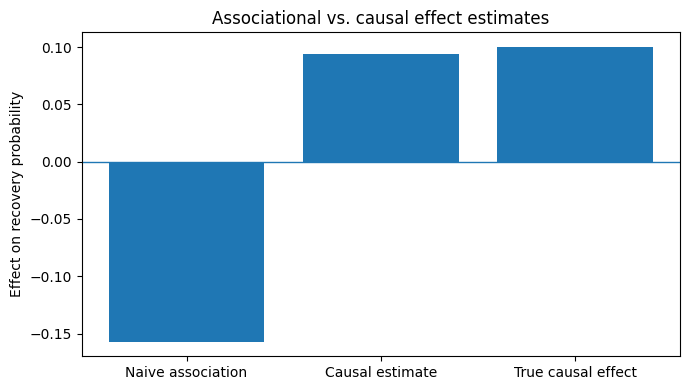

In [18]:
import matplotlib.pyplot as plt

# compare associational, causal, and true effects
plt.figure(figsize=(7, 4))

plt.bar(
    results["Method"],
    results["Effect"]
)

plt.axhline(0, linewidth=1)
plt.ylabel("Effect on recovery probability")
plt.title("Associational vs. causal effect estimates")

plt.tight_layout()
plt.show()

### Interpretation

The naive associational analysis suggests that treatment reduces the probability of recovery by approximately 15.7 percentage points. However, this result is distorted by disease severity, since more severe patients are substantially more likely to receive treatment and are also less likely to recover.

After adjusting for severity using the specified causal model, the estimated average treatment effect is approximately +9.4 percentage points. This is close to the known true causal effect of +10 percentage points defined by the synthetic data-generating process.

The case therefore demonstrates how confounding can not only change the magnitude of an observed relationship, but even reverse its direction, producing a Simpson's paradox.

## Sensitivity Analysis: Strength of Confounding

The main scenario uses strongly severity-dependent treatment assignment. To assess whether the observed reversal depends on this particular parameter choice, the treatment-assignment probabilities are varied while keeping the severity distribution, recovery probabilities, and true treatment effect unchanged.

In [19]:
def simulate_treatment_case(treatment_probs, seed=42, n=10000):
    rng = np.random.default_rng(seed)

    severity_levels = ["mild", "moderate", "severe"]
    severity_probs = [0.40, 0.35, 0.25]

    severity = rng.choice(
        severity_levels,
        size=n,
        p=severity_probs
    )

    treatment_probability = np.select(
        [
            severity == "mild",
            severity == "moderate",
            severity == "severe"
        ],
        treatment_probs
    )

    treatment = rng.binomial(1, treatment_probability)

    baseline_recovery = np.select(
        [
            severity == "mild",
            severity == "moderate",
            severity == "severe"
        ],
        [0.80, 0.60, 0.30]
    )

    recovery_probability = baseline_recovery + 0.10 * treatment
    recovery = rng.binomial(1, recovery_probability)

    df_sim = pd.DataFrame({
        "severity": severity,
        "treatment": treatment,
        "recovery": recovery
    })

    naive = (
        df_sim.groupby("treatment")["recovery"].mean().loc[1]
        - df_sim.groupby("treatment")["recovery"].mean().loc[0]
    )

    df_reg = pd.get_dummies(
        df_sim,
        columns=["severity"],
        drop_first=True,
        dtype=int
    )

    X = np.column_stack([
        np.ones(len(df_reg)),
        df_reg["treatment"],
        df_reg["severity_moderate"],
        df_reg["severity_severe"]
    ])

    beta = np.linalg.lstsq(X, df_reg["recovery"], rcond=None)[0]
    adjusted = beta[1]

    return naive, adjusted

In [20]:
scenarios = {
    "Weak confounding": [0.40, 0.50, 0.60],
    "Moderate confounding": [0.30, 0.50, 0.70],
    "Original strong confounding": [0.10, 0.50, 0.90]
}

sensitivity_results = []

for name, probabilities in scenarios.items():
    naive, adjusted = simulate_treatment_case(probabilities)

    sensitivity_results.append({
        "Scenario": name,
        "Treatment probabilities": str(probabilities),
        "Naive effect": naive,
        "Adjusted effect": adjusted
    })

sensitivity_results = pd.DataFrame(sensitivity_results)

sensitivity_results[["Naive effect", "Adjusted effect"]] = (
    sensitivity_results[["Naive effect", "Adjusted effect"]].round(3)
)

sensitivity_results

,Scenario,Treatment probabilities,Naive effect,Adjusted effect
0,Weak confounding,"[0.4, 0.5, 0.6]",0.048,0.102
1,Moderate confounding,"[0.3, 0.5, 0.7]",-0.019,0.100
2,Original strong confounding,"[0.1, 0.5, 0.9]",-0.157,0.094


### Sensitivity Analysis Interpretation

The sensitivity analysis shows that the discrepancy between associational and causal estimates increases as the strength of confounding increases. Under weak confounding, the naive estimate remains positive at approximately +0.048 but substantially underestimates the true causal effect of +0.10. Under moderate confounding, the naive estimate becomes slightly negative at approximately -0.019, while under the original strong-confounding scenario it decreases to approximately -0.157.

In contrast, the adjusted estimates remain close to the known causal effect across all three scenarios. This indicates that the qualitative disagreement between associational and causal analysis depends not only on the presence of confounding, but also on its strength.